**Online learning engagement & Dropout risk analysis**

-Objective: to analyze student engagement patterns and identify factors associated with dropout risk in online learning platforms.

-key questions:
1. Does engagement reduce dropout risk?
2. Does device type influence dropout?
3. Does course category influence dropout?
4. Which engagement metrics are most associated with dropout risk?

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

**Load Dataset**

source: Kaggle

Dataset: Online Learning Engagement and Dropout Risk

In [ ]:
import os
import kagglehub
path = kagglehub.dataset_download("jayjoshi37/online-learning-engagement-and-dropout-risk")
file_path = os.path.join(path, "online_learning_engagement_dropout_risk.csv")

df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'online-learning-engagement-and-dropout-risk' dataset.


,student_id,course_category,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent,device_type,dropout_risk
0,1,Design,14,17,51,7,60.42,14,23,Desktop,Low
1,2,AI & ML,8,26,1,10,77.25,33,29,Tablet,Medium
2,3,Business,6,26,24,1,93.46,23,82,Desktop,Low
3,4,AI & ML,5,99,12,7,69.77,32,92,Desktop,Low
4,5,AI & ML,13,150,97,3,89.48,40,34,Tablet,Low


**Data Overview**

In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()


Shape: (2800, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                2800 non-null   int64  
 1   course_category           2800 non-null   object 
 2   login_frequency_per_week  2800 non-null   int64  
 3   avg_session_minutes       2800 non-null   int64  
 4   course_progress_percent   2800 non-null   int64  
 5   assignments_completed     2800 non-null   int64  
 6   quiz_average_score        2800 non-null   float64
 7   forum_interactions        2800 non-null   int64  
 8   video_watch_percent       2800 non-null   int64  
 9   device_type               2800 non-null   object 
 10  dropout_risk              2800 non-null   object 
dtypes: float64(1), int64(7), object(3)
memory usage: 240.8+ KB


,0
student_id,0
course_category,0
login_frequency_per_week,0
avg_session_minutes,0
course_progress_percent,0
assignments_completed,0
quiz_average_score,0
forum_interactions,0
video_watch_percent,0
device_type,0


**Categorical Distributions**

In [ ]:
categorical_cols=['device_type', 'dropout_risk', 'course_category']

for col in categorical_cols:
  print(f'\nValue counts for {col}:')
  print(df[col].value_counts())



Value counts for device_type:
device_type
Desktop    957
Tablet     924
Mobile     919
Name: count, dtype: int64

Value counts for dropout_risk:
dropout_risk
Low       1360
Medium     847
High       593
Name: count, dtype: int64

Value counts for course_category:
course_category
Design          581
AI & ML         567
Data Science    567
Programming     557
Business        528
Name: count, dtype: int64


**Distribution of Login Frequency**

8.0
7.498571428571428
-0.018275145643864937


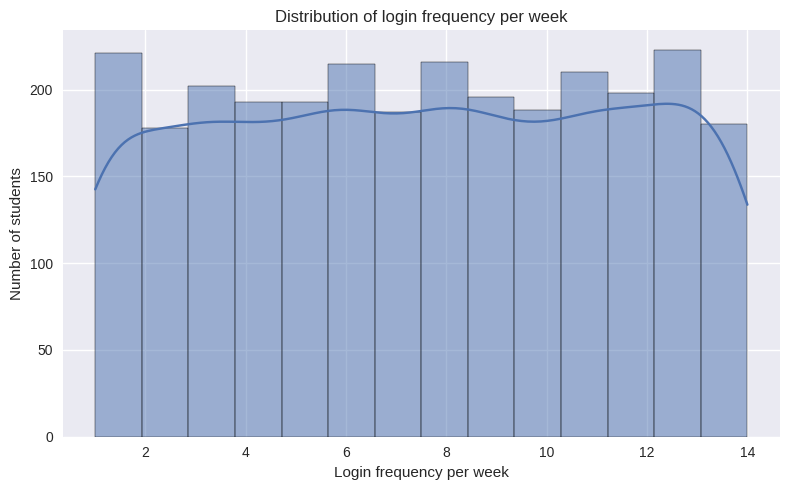

In [ ]:
print(df["login_frequency_per_week"].median())
print(df["login_frequency_per_week"].mean())
print(df["login_frequency_per_week"].skew())
print("=" * 80)
plt.figure(figsize=(8,5))
sns.histplot(df["login_frequency_per_week"], kde=True)
plt.title("Distribution of login frequency per week")
plt.xlabel("Login frequency per week")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()

**Engagement vs Course Performance**

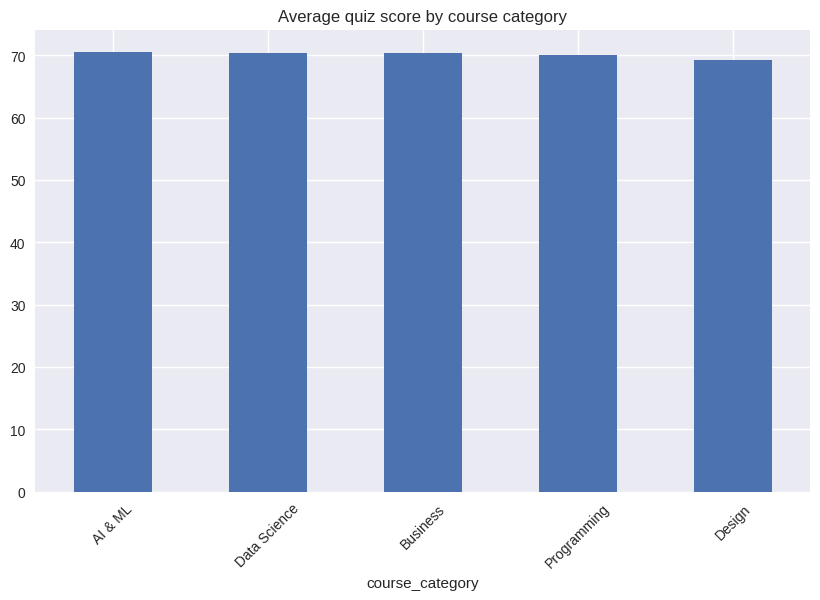

In [ ]:
quiz_by_course = (
    df.groupby("course_category")['quiz_average_score']
    .mean()
    .sort_values(ascending=False)
)

quiz_by_course.plot(kind='bar', figsize=(10,6))
plt.title("Average quiz score by course category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Engagement by Dropout Risk**

In [ ]:
engagement_cols = [
    'login_frequency_per_week',
    'avg_session_minutes',
    'assignments_completed',
    'quiz_average_score',
    'forum_interactions',
    'video_watch_percent',
    'course_progress_percent'
]

engagement_by_dropout = (
    df.groupby('dropout_risk')[engagement_cols]
      .mean()
      .round(2)
)

engagement_by_dropout

,login_frequency_per_week,avg_session_minutes,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent,course_progress_percent
dropout_risk,,,,,,,
High,7.40,93.58,5.71,71.01,24.08,59.54,53.20
Low,7.53,94.27,5.63,69.70,24.84,60.36,49.97
Medium,7.52,94.64,5.52,70.21,24.73,60.61,49.81


**Device Type vs Dropout Risk**

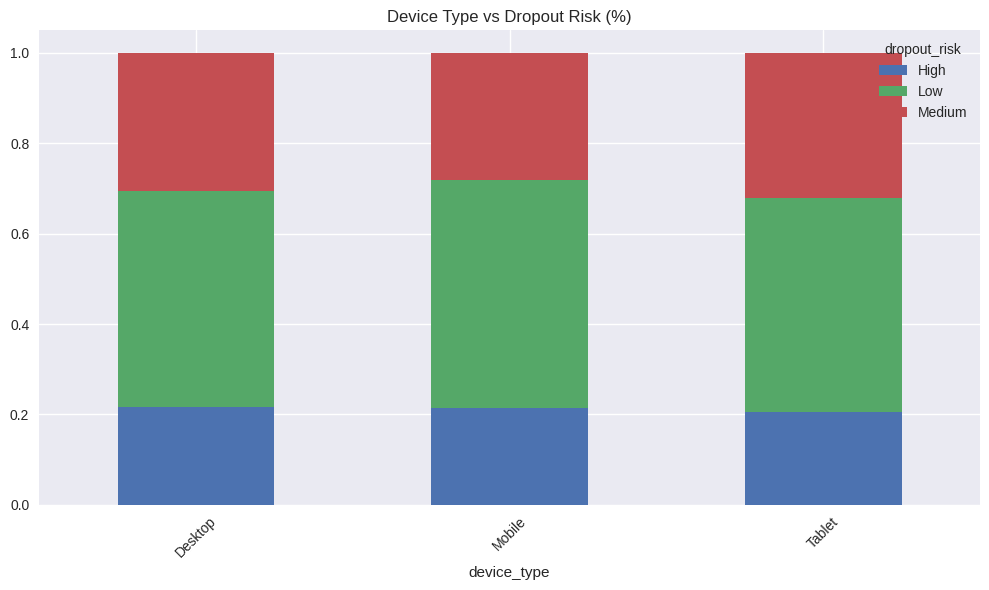

In [ ]:
ct_device = pd.crosstab(
    df['device_type'],
    df['dropout_risk'],
    normalize='index'
)

ct_device.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Device Type vs Dropout Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Course Category vs Dropout Risk**

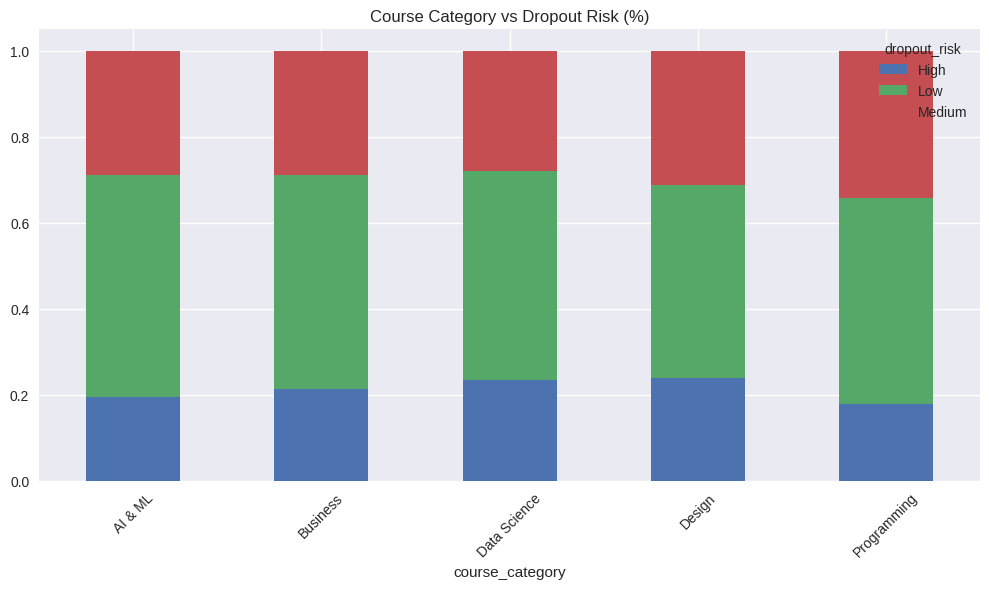

In [ ]:
ct_course = pd.crosstab(
    df['course_category'],
    df['dropout_risk'],
    normalize='index'
)

ct_course.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Course Category vs Dropout Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Correlation with Dropout Risk**

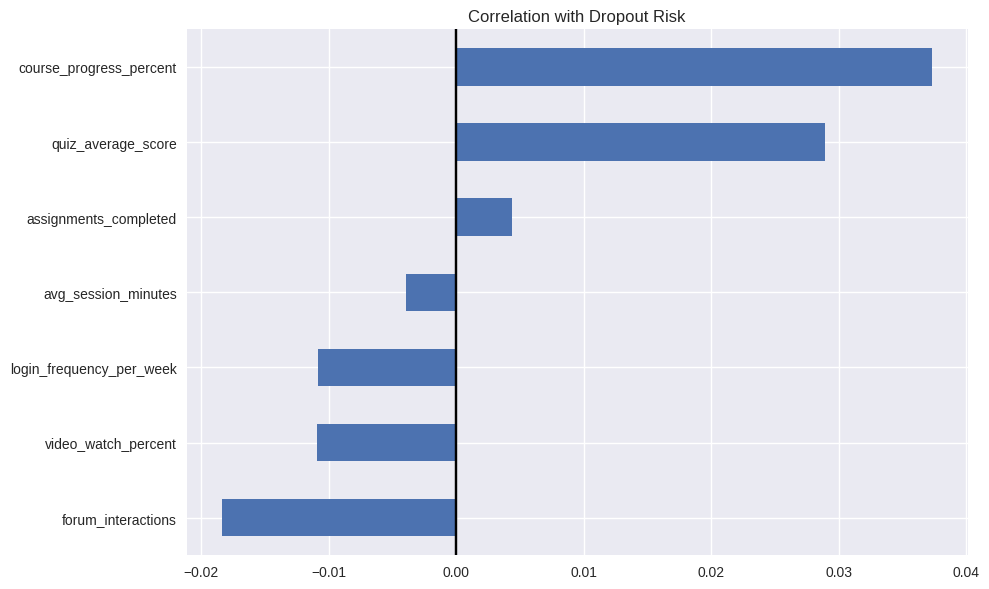

In [ ]:
df_numeric = df.copy()

df_numeric['dropout_risk_numeric'] = df_numeric['dropout_risk'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

correlations = (
    df_numeric[engagement_cols + ['dropout_risk_numeric']]
    .corr()['dropout_risk_numeric']
    .sort_values()
)

correlations

correlations[:-1].plot(kind='barh', figsize=(10,6))
plt.title("Correlation with Dropout Risk")
plt.axvline(x=0, color='black')
plt.tight_layout()
plt.show()

**Key Findings
**
1. Engagement metrics such as login frequency, assignments completed, and course progress are negatively correlated with dropout risk.

2. Course category shows greater variation in dropout rates compared to device type.

3. Students with lower quiz scores and lower interaction levels tend to have higher dropout risk.

## Conclusion

Student engagement is the primary driver of retention in online learning.
The platform should prioritize interventions targeting low engagement: increased
login frequency, assignment completion, and course progress. While course
content quality varies by category, device type does not meaningfully impact
dropout risk, suggesting responsive design is sufficient. Future work could
include predictive modeling to identify at-risk students early